# Árbol de Decisión — Clasificación de Golf

## 1. Importaciones
Bibliotecas para carga de datos, modelado, evaluación y visualización del árbol.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

## 2. Carga y exploración de datos
Dataset clásico de 14 observaciones con cuatro variables climáticas (`outlook`, `temp`, `humidity`, `windy`) y la decisión binaria de jugar al golf (`play`).

In [2]:
df = pd.read_csv('golf.csv')
df

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [3]:
df.info()
print()
for col in df.columns:
    print(f'{col}:')
    print(df[col].value_counts().to_string(), '\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   outlook   14 non-null     object
 1   temp      14 non-null     object
 2   humidity  14 non-null     object
 3   windy     14 non-null     bool  
 4   play      14 non-null     object
dtypes: bool(1), object(4)
memory usage: 594.0+ bytes

outlook:
outlook
sunny       5
rainy       5
overcast    4 

temp:
temp
mild    6
hot     4
cool    4 

humidity:
humidity
high      7
normal    7 

windy:
windy
False    8
True     6 

play:
play
yes    9
no     5 



## 3. Análisis de correlaciones
Las variables son categóricas, por lo que se codifican numéricamente con `LabelEncoder` para calcular la correlación de Pearson. Valores cercanos a ±1 indican mayor asociación lineal con la variable objetivo.

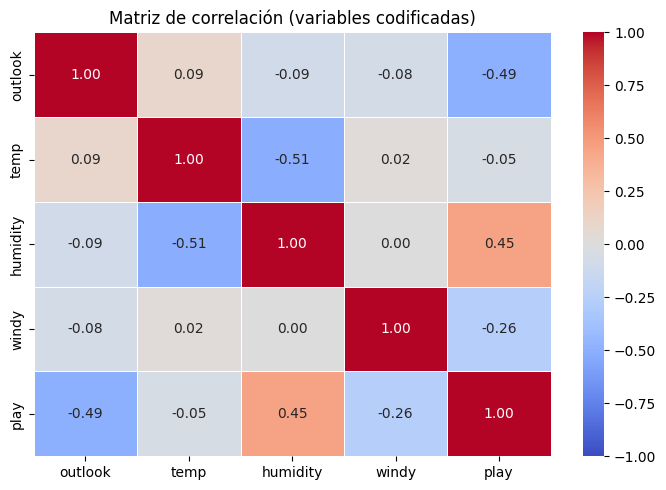

In [4]:
df_num = df.copy()
le = LabelEncoder()
for col in df_num.columns:
    df_num[col] = le.fit_transform(df_num[col].astype(str))

plt.figure(figsize=(7, 5))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Matriz de correlación (variables codificadas)')
plt.tight_layout()
plt.show()

### Distribución por variable
Conteos de jugar / no jugar para cada categoría de cada variable, para identificar visualmente las más discriminativas.

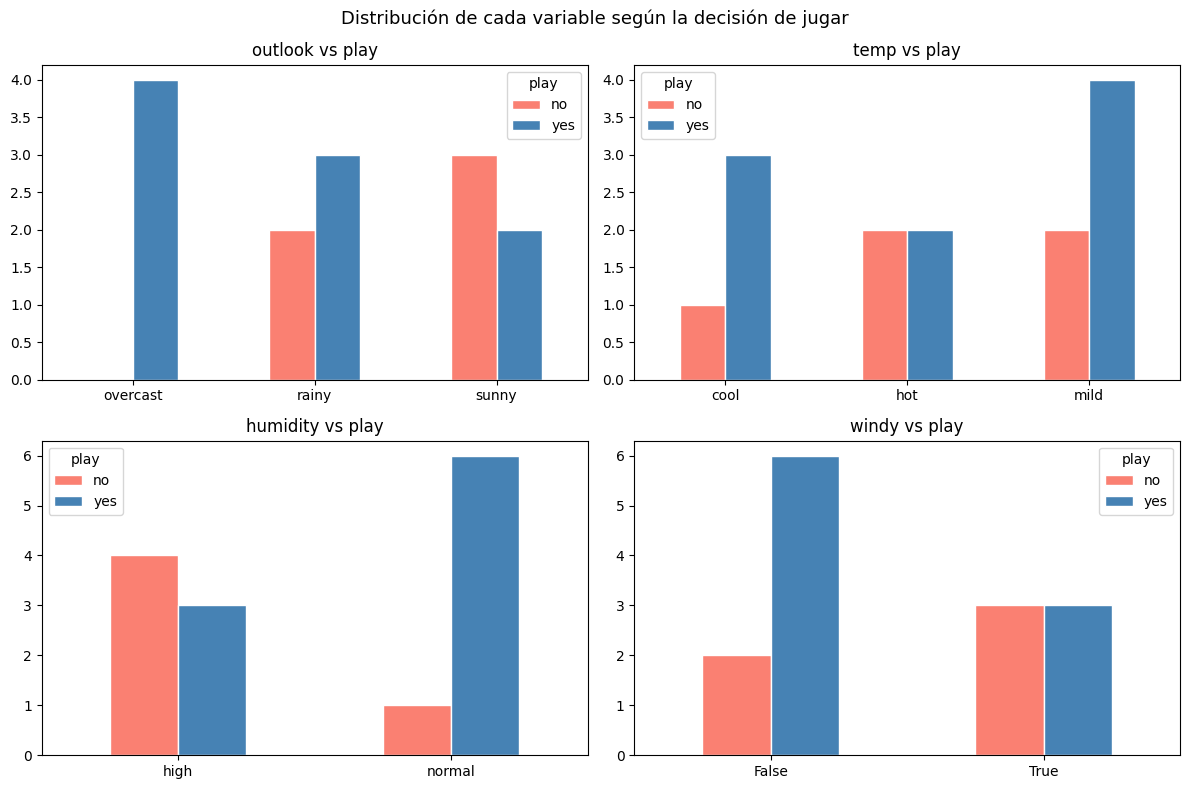

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ['outlook', 'temp', 'humidity', 'windy']):
    df.groupby([col, 'play']).size().unstack(fill_value=0).plot(
        kind='bar', ax=ax, color=['salmon', 'steelblue'], edgecolor='white')
    ax.set_title(f'{col} vs play')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='play')
plt.suptitle('Distribución de cada variable según la decisión de jugar', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Preprocesamiento
`pd.get_dummies` aplica *one-hot encoding* a las variables categóricas generando una columna binaria por cada categoría. `windy` (booleano) se convierte a entero. La variable objetivo se codifica como 0 = *no* y 1 = *yes*.

In [6]:
df_prep = df.drop('play', axis=1).copy()
df_prep['windy'] = df_prep['windy'].astype(int)

X = pd.get_dummies(df_prep)
y = (df['play'] == 'yes').astype(int)

print('Features:', X.columns.tolist())
print('Forma de X:', X.shape)
X

Features: ['windy', 'outlook_overcast', 'outlook_rainy', 'outlook_sunny', 'temp_cool', 'temp_hot', 'temp_mild', 'humidity_high', 'humidity_normal']
Forma de X: (14, 9)


,windy,outlook_overcast,outlook_rainy,outlook_sunny,temp_cool,temp_hot,temp_mild,humidity_high,humidity_normal
0,0,False,False,True,False,True,False,True,False
1,1,False,False,True,False,True,False,True,False
2,0,True,False,False,False,True,False,True,False
3,0,False,True,False,False,False,True,True,False
4,0,False,True,False,True,False,False,False,True
5,1,False,True,False,True,False,False,False,True
6,1,True,False,False,True,False,False,False,True
7,0,False,False,True,False,False,True,True,False
8,0,False,False,True,True,False,False,False,True
9,0,False,True,False,False,False,True,False,True


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
print(f'Entrenamiento : {len(X_train)} muestras  →  play=yes: {y_train.sum()}, play=no: {(y_train==0).sum()}')
print(f'Prueba        : {len(X_test)}  muestras  →  play=yes: {y_test.sum()}, play=no: {(y_test==0).sum()}')

Entrenamiento : 9 muestras  →  play=yes: 6, play=no: 3
Prueba        : 5  muestras  →  play=yes: 3, play=no: 2


## 5. Entrenamiento del árbol de decisión
Se usa `criterion='entropy'` (ganancia de información — algoritmo ID3), que es el criterio original diseñado para este dataset clásico. Sin restricción de `max_depth` el árbol crece hasta clasificar perfectamente el conjunto de entrenamiento.

In [8]:
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)
print(f'Profundidad del árbol entrenado: {clf.get_depth()}')
print(f'Número de hojas               : {clf.get_n_leaves()}')

Profundidad del árbol entrenado: 3
Número de hojas               : 4


## 6. Evaluación
Se mide el desempeño en el conjunto de prueba con *accuracy*, reporte de clasificación y matriz de confusión. Dado el tamaño reducido del dataset (14 muestras), se complementa con validación cruzada de 5 pliegues para una estimación más robusta.

Accuracy en prueba: 0.40

              precision    recall  f1-score   support

          no       0.00      0.00      0.00         2
         yes       0.50      0.67      0.57         3

    accuracy                           0.40         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.30      0.40      0.34         5



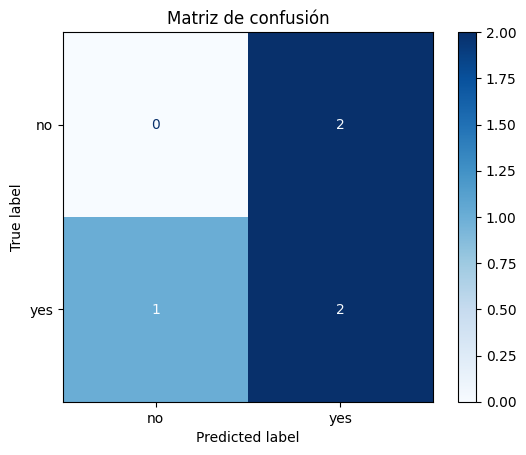

In [9]:
y_pred = clf.predict(X_test)

print(f'Accuracy en prueba: {accuracy_score(y_test, y_pred):.2f}\n')
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['no', 'yes'], cmap='Blues')
plt.title('Matriz de confusión')
plt.show()

In [10]:
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print(f'CV accuracy (5-fold): {cv_scores.mean():.2f} ± {cv_scores.std():.2f}')
print(f'Scores por fold     : {cv_scores.round(2)}')

CV accuracy (5-fold): 0.80 ± 0.16
Scores por fold     : [0.67 1.   0.67 0.67 1.  ]


## 7. Visualización del árbol
Cada nodo muestra: la **condición de división**, la **entropía** (impureza), el número de **muestras** y la distribución de clases. Los nodos coloreados indican la clase mayoritaria: naranja = *no*, azul = *yes*.

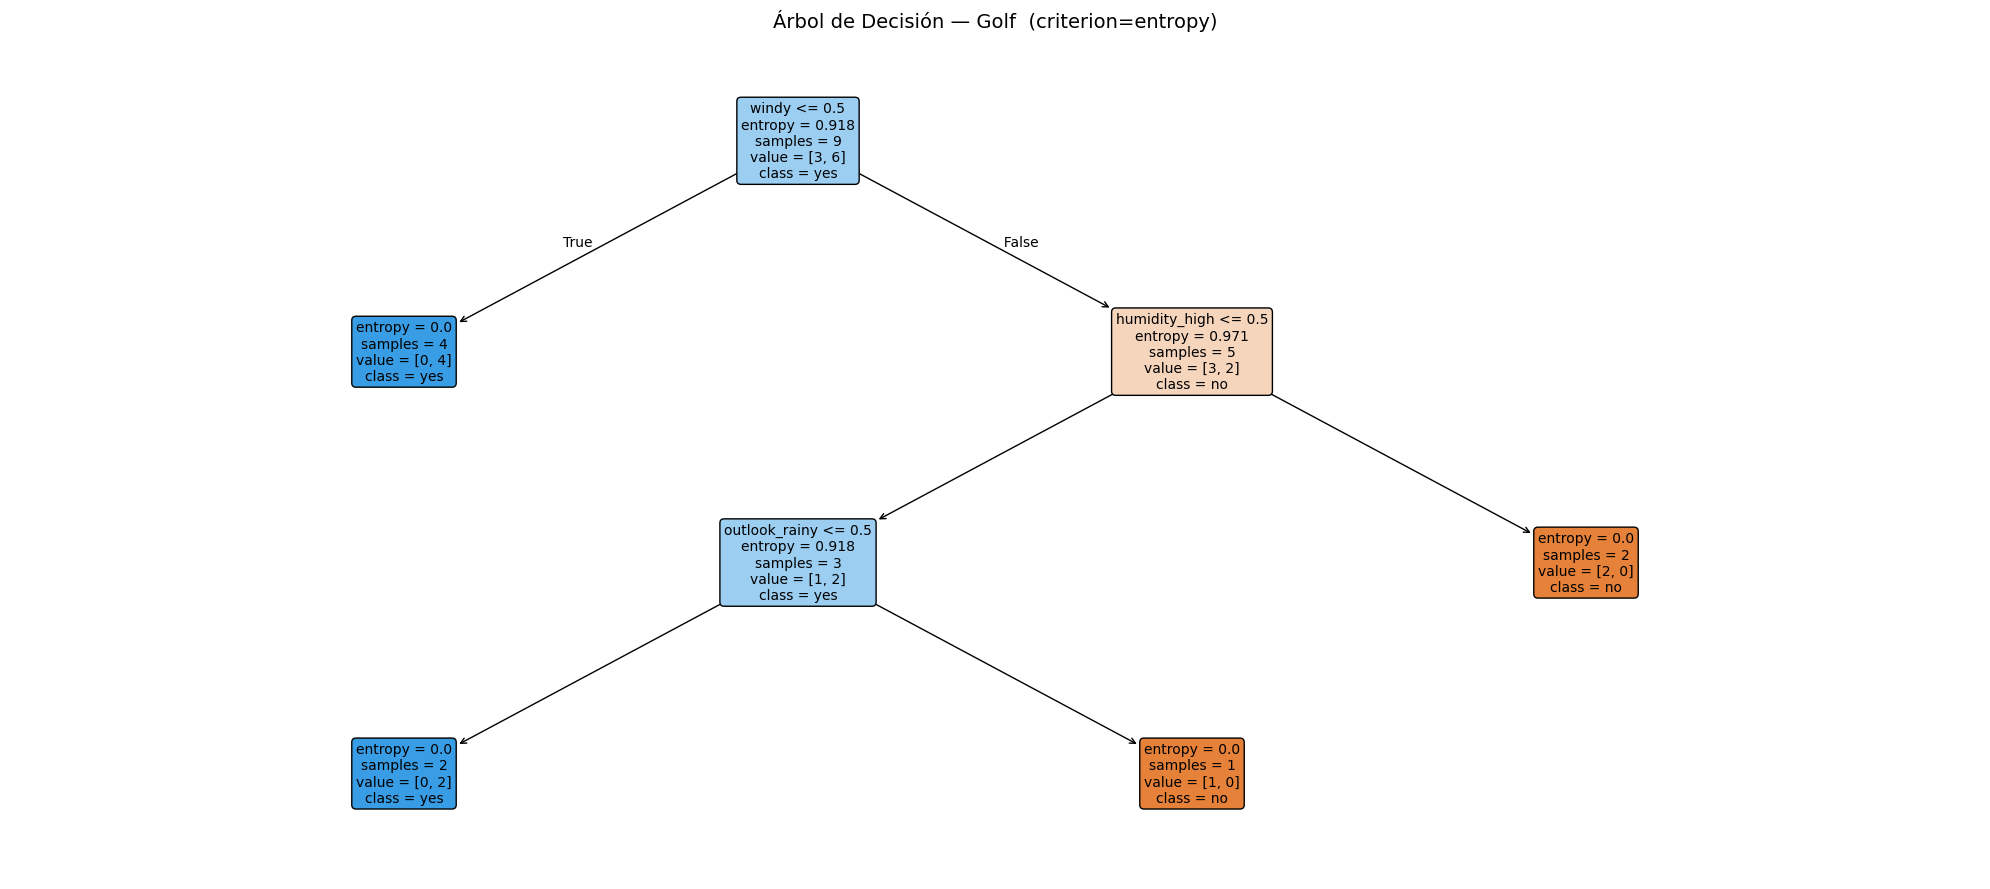

In [11]:
plt.figure(figsize=(20, 9))
plot_tree(clf,
          feature_names=X.columns.tolist(),
          class_names=['no', 'yes'],
          filled=True, rounded=True, fontsize=10)
plt.title('Árbol de Decisión — Golf  (criterion=entropy)', fontsize=14)
plt.tight_layout()
plt.show()

### Representación textual
`export_text` muestra las mismas reglas de decisión en formato de texto plano, útil para auditar o documentar el modelo.

In [12]:
print(export_text(clf, feature_names=X.columns.tolist()))

|--- windy <= 0.50
|   |--- class: 1
|--- windy >  0.50
|   |--- humidity_high <= 0.50
|   |   |--- outlook_rainy <= 0.50
|   |   |   |--- class: 1
|   |   |--- outlook_rainy >  0.50
|   |   |   |--- class: 0
|   |--- humidity_high >  0.50
|   |   |--- class: 0



## 8. Importancia de características
La importancia de cada variable se calcula como la **reducción media ponderada de entropía** que aporta en todos los nodos donde aparece. Variables con mayor importancia son más discriminativas para la decisión de jugar.

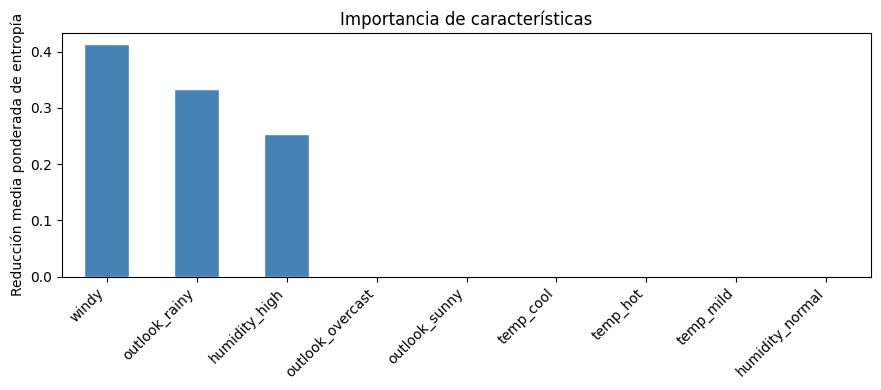

windy               0.4126
outlook_rainy       0.3333
humidity_high       0.2541
outlook_overcast    0.0000
outlook_sunny       0.0000
temp_cool           0.0000
temp_hot            0.0000
temp_mild           0.0000
humidity_normal     0.0000


In [13]:
importances = (pd.Series(clf.feature_importances_, index=X.columns)
               .sort_values(ascending=False))

importances.plot(kind='bar', color='steelblue', edgecolor='white', figsize=(9, 4))
plt.title('Importancia de características')
plt.ylabel('Reducción media ponderada de entropía')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(importances.round(4).to_string())

## 9. Optimización de hiperparámetros
Se evalúan dos hiperparámetros clave:
- **`max_depth`**: controla la profundidad máxima del árbol. Valores bajos simplifican el modelo (menos sobreajuste); valores altos permiten capturar relaciones más complejas.
- **`criterion`**: `'entropy'` usa ganancia de información (ID3); `'gini'` usa el índice de Gini (CART). Ambos suelen producir árboles similares pero con diferente geometría de división.

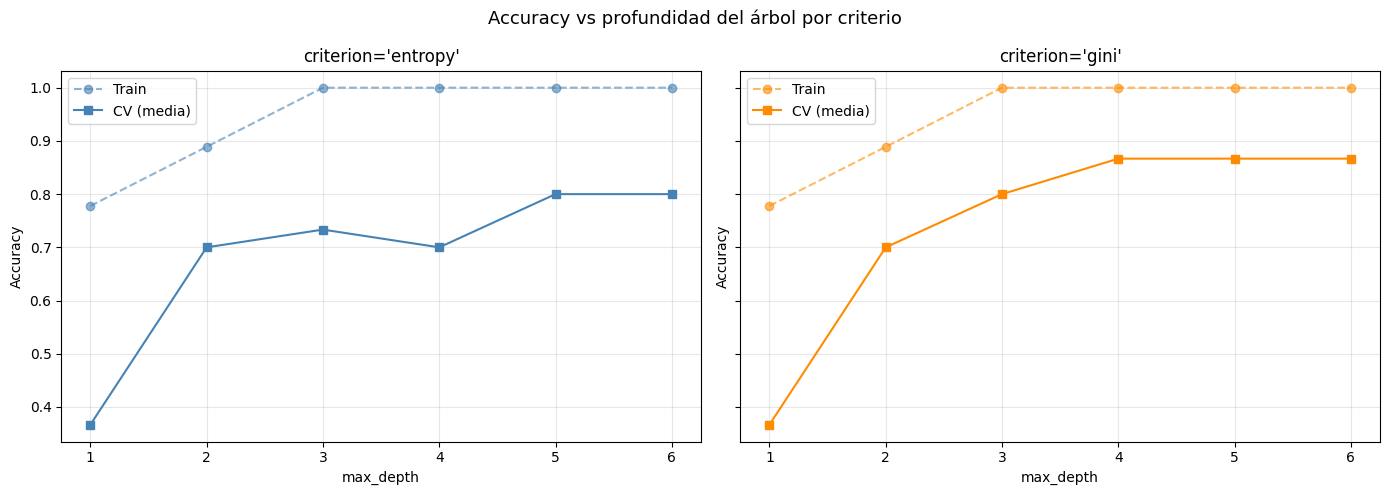

In [14]:
depths = range(1, 7)
results = {k: [] for k in ['entropy_train', 'entropy_cv', 'gini_train', 'gini_cv']}

for d in depths:
    for crit in ['entropy', 'gini']:
        m = DecisionTreeClassifier(criterion=crit, max_depth=d, random_state=42)
        m.fit(X_train, y_train)
        results[f'{crit}_train'].append(m.score(X_train, y_train))
        results[f'{crit}_cv'].append(cross_val_score(m, X, y, cv=5).mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, crit, color in zip(axes, ['entropy', 'gini'], ['steelblue', 'darkorange']):
    ax.plot(list(depths), results[f'{crit}_train'], 'o--',
            label='Train', color=color, alpha=0.6)
    ax.plot(list(depths), results[f'{crit}_cv'], 's-',
            label='CV (media)', color=color)
    ax.set_title(f"criterion='{crit}'")
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(list(depths))
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('Accuracy vs profundidad del árbol por criterio', fontsize=13)
plt.tight_layout()
plt.show()

### Árbol con profundidad óptima
Seleccionando la profundidad donde la CV es máxima se obtiene el modelo más generalizable. Con solo 14 muestras, un árbol de profundidad 2–3 suele ser suficiente.

Mejor max_depth (entropy, CV): 5


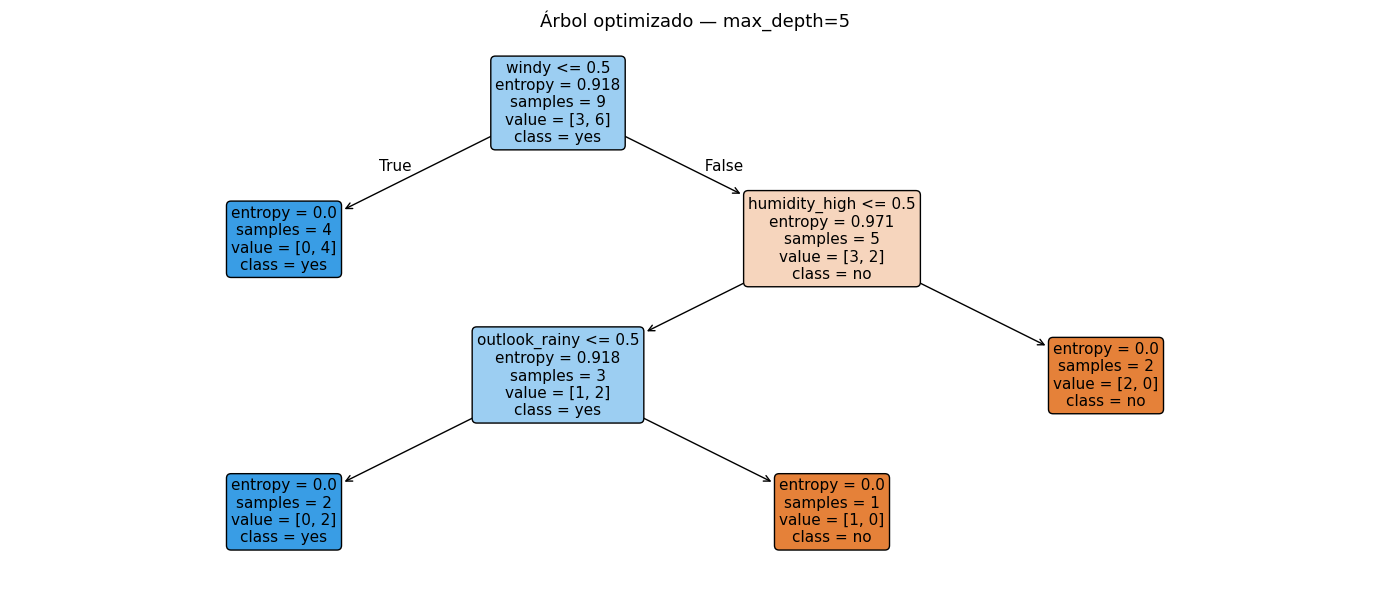

|--- windy <= 0.50
|   |--- class: 1
|--- windy >  0.50
|   |--- humidity_high <= 0.50
|   |   |--- outlook_rainy <= 0.50
|   |   |   |--- class: 1
|   |   |--- outlook_rainy >  0.50
|   |   |   |--- class: 0
|   |--- humidity_high >  0.50
|   |   |--- class: 0



In [15]:
best_depth = int(np.argmax(results['entropy_cv'])) + 1
print(f'Mejor max_depth (entropy, CV): {best_depth}')

clf_opt = DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, random_state=42)
clf_opt.fit(X_train, y_train)

plt.figure(figsize=(14, 6))
plot_tree(clf_opt,
          feature_names=X.columns.tolist(),
          class_names=['no', 'yes'],
          filled=True, rounded=True, fontsize=11)
plt.title(f'Árbol optimizado — max_depth={best_depth}', fontsize=13)
plt.tight_layout()
plt.show()

print(export_text(clf_opt, feature_names=X.columns.tolist()))